In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv('Resume_25.csv', engine = 'python', on_bad_lines = 'skip')
df = pd.DataFrame(data)
df.shape

(2679, 2)

In [70]:
col1 = df.Category.unique()

In [71]:
df['Category'].value_counts()

,count
Category,
HR,154
BUSINESS-DEVELOPMENT,120
INFORMATION-TECHNOLOGY,120
ADVOCATE,118
CHEF,118
ENGINEERING,118
ACCOUNTANT,118
FINANCE,118
FITNESS,117


In [72]:
df.Category.nunique()

25

In [73]:
df.head()

,Category,Resume
0,HR,TECHNICAL SKILLS â¢ Typewriting â¢ TORA â¢ ...
1,HR,"I.T. Skills â¢ Windows XP, Ms Office (Word, E..."
2,HR,Education Details \r\n BA mumbai University\...
3,HR,Education Details \r\nJune 2012 to May 2015 B....
4,HR,Education Details \r\nJune 2012 to May 2015 B....


In [74]:
df.iloc[40:60]

,Category,Resume
40,HR,KEY SKILLS: â¢ Computerized accounting with t...
41,HR,Training in Special Education (Certificate Cou...
42,HR,Computer Knowledge: â¢ Proficient in basic us...
43,HR,SOFTWARE SKILLS: â¢ General Computer Proficie...
44,Java Developer,Education Details \r\nAugust 2010 to May 2017 ...
45,Java Developer,Technical Skills (Trained / Project Acquired S...
46,Java Developer,"TECHNICAL SKILLS Skills: Java, SQL, PL/SQL, C,..."
47,Java Developer,TECHNICAL STRENGTHS Computer Language Java/J2E...
48,Java Developer,Education Details \r\nJanuary 2013 Master of E...
49,Java Developer,Education Details \r\n BE IT pjlce\r\nJava D...


In [75]:
df.Category.unique()

array(['HR', 'Java Developer', 'DevOps Engineer', 'Testing', 'DESIGNER',
       'INFORMATION-TECHNOLOGY', 'TEACHER', 'ADVOCATE',
       'BUSINESS-DEVELOPMENT', 'HEALTHCARE', 'FITNESS', 'AGRICULTURE',
       'SALES', 'CONSULTANT', 'DIGITAL-MEDIA', 'CHEF', 'FINANCE',
       'APPAREL', 'ENGINEERING', 'ACCOUNTANT', 'CONSTRUCTION',
       'PUBLIC-RELATIONS', 'BANKING', 'ARTS', 'AVIATION'], dtype=object)

<Axes: xlabel='count', ylabel='Category'>

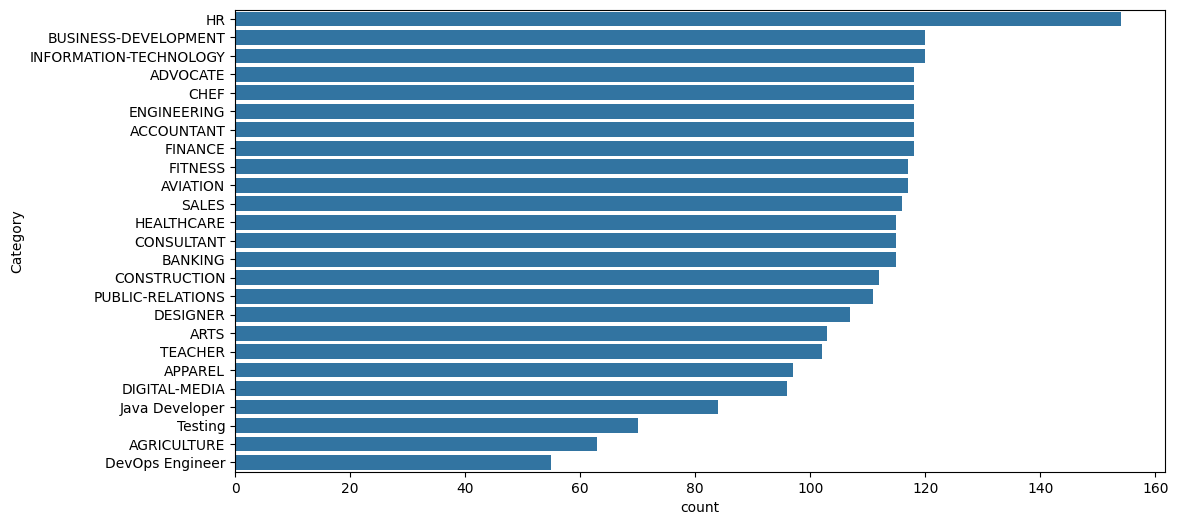

In [76]:
import seaborn as sns
plt.figure(figsize=(12,6))

sns.countplot(
    y=df['Category'],
    order=df['Category'].value_counts().index
)


In [77]:
import nltk
import re

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [78]:
stopword = nltk.corpus.stopwords.words('english')


In [79]:
# Download necessary NLTK data for lemmatization
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [80]:
def clean_resume(text):
  # Convert to lowercase
  text = text.lower()

  # Remove URLs
  text = re.sub(r'https?\S+|www\S+', ' ', text)

  # Remove mentions (e.g., @user)
  text = re.sub(r'\s+@\S+', ' ', text)

  # Remove special characters, numbers, and punctuation, but keep spaces
  # Modified regex to retain alphanumeric characters and spaces
  text = re.sub(r'[^a-zA-Z0-9 ]', '', text)

  # Remove extra spaces
  text = re.sub(r'\s+', ' ', text).strip()

  # Tokenize and remove stopwords
  words = text.split()
  words = [lemmatizer.lemmatize(word) for word in words if word not in stopword]

  return " ".join(words)

df['clean_resume'] = df['Resume'].apply(clean_resume)


In [81]:
df['clean_resume'].iloc[0]

'technical skill typewriting tora spsseducation detail january 2017 mba chidambaram tamil nadu sn college engineeringjanuary 2014 hsc sav higher secondary school mba sn college engineering sslc finance kamaraj matriculation schoolhr skill detail human resource finance exprience less 1 year monthscompany detail company description'

In [82]:
df[['clean_resume','Resume']].head()

,clean_resume,Resume
0,technical skill typewriting tora spsseducation...,TECHNICAL SKILLS â¢ Typewriting â¢ TORA â¢ ...
1,skill window xp m office word excel lookup piv...,"I.T. Skills â¢ Windows XP, Ms Office (Word, E..."
2,education detail ba mumbai universityhr skill ...,Education Details \r\n BA mumbai University\...
3,education detail june 2012 may 2015 ba economi...,Education Details \r\nJune 2012 to May 2015 B....
4,education detail june 2012 may 2015 ba economi...,Education Details \r\nJune 2012 to May 2015 B....


In [83]:
df.drop('Resume',axis =1, inplace = True)

In [84]:
df.rename(columns ={'clean_resume' : 'Resume'}, inplace = True)

In [85]:
df.head()

,Category,Resume
0,HR,technical skill typewriting tora spsseducation...
1,HR,skill window xp m office word excel lookup piv...
2,HR,education detail ba mumbai universityhr skill ...
3,HR,education detail june 2012 may 2015 ba economi...
4,HR,education detail june 2012 may 2015 ba economi...


In [86]:
df.isna().sum()

,0
Category,0
Resume,0


In [87]:
df.duplicated().sum()

np.int64(218)

In [88]:
df.drop_duplicates(inplace=True)

In [89]:
df.duplicated().sum()

np.int64(0)

In [90]:
print(df.shape)

print(df.columns)

df['Category'].nunique()

(2461, 2)
Index(['Category', 'Resume'], dtype='object')


25

In [91]:
df['Category'].value_counts()

,count
Category,
HR,120
BUSINESS-DEVELOPMENT,120
INFORMATION-TECHNOLOGY,120
ADVOCATE,118
CHEF,118
ENGINEERING,118
ACCOUNTANT,118
FITNESS,117
FINANCE,117


In [92]:
df.Category.unique()

array(['HR', 'Java Developer', 'DevOps Engineer', 'Testing', 'DESIGNER',
       'INFORMATION-TECHNOLOGY', 'TEACHER', 'ADVOCATE',
       'BUSINESS-DEVELOPMENT', 'HEALTHCARE', 'FITNESS', 'AGRICULTURE',
       'SALES', 'CONSULTANT', 'DIGITAL-MEDIA', 'CHEF', 'FINANCE',
       'APPAREL', 'ENGINEERING', 'ACCOUNTANT', 'CONSTRUCTION',
       'PUBLIC-RELATIONS', 'BANKING', 'ARTS', 'AVIATION'], dtype=object)

In [93]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [94]:
x = df['Resume']
y = df['Category']

In [95]:
x.shape

(2461,)

In [96]:

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2
)

x = tfidf.fit_transform(x)
print(x.shape)


(2461, 10000)


In [97]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42, stratify = y)

In [98]:
x_train.shape,x_test.shape

((1968, 10000), (493, 10000))

In [99]:
df.iloc[1969:2000]

,Category,Resume
2186,CONSTRUCTION,commercial project manager construction manage...
2187,CONSTRUCTION,new construction afe maintenance manager summa...
2188,CONSTRUCTION,facility design construction project manager s...
2189,CONSTRUCTION,laboer floor construction worker round experie...
2190,CONSTRUCTION,construction equipment repairer shop foreman s...
2191,CONSTRUCTION,senior construction safety project manager sum...
2192,CONSTRUCTION,construction manager project coordinator inspe...
2193,CONSTRUCTION,senior facility construction project manager s...
2194,CONSTRUCTION,administrative associate ii construction manag...
2195,CONSTRUCTION,assistant project managerdesign build construc...


In [100]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier

In [101]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [102]:
lr = LogisticRegression()
lr_fit = lr.fit(x_train,y_train)
lr_pred = lr_fit.predict(x_test)

print(accuracy_score(y_test,lr_pred))

0.6815415821501014


In [103]:
dcr = DecisionTreeClassifier()
dcr_fit = dcr.fit(x_train,y_train)
dcr_pred = dcr_fit.predict(x_test)

print(accuracy_score(dcr_pred,y_test))

0.6206896551724138


In [104]:
rfc = RandomForestClassifier()
rfc_fit = rfc.fit(x_train,y_train)
rfc_pred = rfc_fit.predict(x_test)

print(accuracy_score(rfc_pred,y_test))

0.7322515212981744


In [106]:
rfc = pd.DataFrame(rfc_pred)

In [107]:
rfc.nunique()

,0
0,24


In [108]:
knn = KNeighborsClassifier()
knn_fit = knn.fit(x_train,y_train)
knn_pred = knn_fit.predict(x_test)

print(accuracy_score(y_test,knn_pred))

0.5496957403651116


In [109]:
nb = MultinomialNB()
nb_fit = nb.fit(x_train,y_train)
nb_pred = nb_fit.predict(x_test)

print(accuracy_score(nb_pred,y_test))

0.5801217038539553


In [110]:
svc = SVC(kernel = 'linear', C = 1, random_state=42)
svc_fit = svc.fit(x_train,y_train)
svc_pred = svc_fit.predict(x_test)

print(accuracy_score(y_test,svc_pred))

0.6937119675456389


In [111]:
from sklearn.svm import LinearSVC
model = LinearSVC()

model.fit(x_train, y_train)

pred = model.predict(x_test)

accuracy_score(y_test, pred)

0.7403651115618661

In [126]:
print(pred[10])

DESIGNER


Testing


In [116]:
def new_pred(text):
  text = text.lower()
  text = re.sub(r'https?\S+|www\S+', ' ', text)
  text = re.sub(r'\s+@\S+', ' ', text)
  text = re.sub(r'[^a-zA-Z0-9 ]', ' ', text)
  text = re.sub(r'\s+', ' ', text).strip()
  words = text.split()
  words = [lemmatizer.lemmatize(word) for word in words if word not in stopword]
  cleaned_txt = " ".join(words)
  x = tfidf.transform([cleaned_txt])  # Pass cleaned_txt as a list
  pred = model.predict(x)
  return pred

In [117]:
resume = """"
Seeking an Information Technology role where I can apply
my technical skills in software development, networking,
database management, and system administration.

Skills:

Programming Languages:
Python, Java, C++, SQL

Database:
MySQL, MongoDB

Operating Systems:
Windows, Linux

Networking:
TCP/IP, DNS, DHCP, Routing

Cloud:
AWS Basics

Tools:
Git, GitHub, VS Code"""

In [118]:
new_pred(resume)

array(['INFORMATION-TECHNOLOGY'], dtype=object)

In [120]:
finance_res = """MBA Finance

Skills:
Financial Analysis
Investment Banking
Portfolio Management
Risk Management
Financial Modeling
Excel
Power BI

Experience:
Analyzed company financial statements.
Created investment reports and valuation models.
Worked on budgeting and forecasting.

Tools:
Excel
Power BI
SAP
Bloomberg Terminal"""

In [121]:
new_pred(finance_res)

array(['BANKING'], dtype=object)

In [122]:
accountant_res = """Skills:
Accounting
Bookkeeping
GST Filing
Taxation
Tally ERP
QuickBooks
Auditing

Experience:
Maintained company ledgers.
Prepared balance sheets and profit-loss statements.
Handled payroll and tax filing.

Tools:
Tally ERP
Excel
QuickBooks"""

In [123]:
new_pred(accountant_res)

array(['ACCOUNTANT'], dtype=object)

In [127]:
teach_res = """Master of Science

Skills:
Classroom Management
Lesson Planning
Student Assessment
Curriculum Development

Experience:
Taught Mathematics and Science.
Prepared study materials.
Evaluated student performance.

Tools:
Google Classroom
Microsoft PowerPoin"""

In [128]:
new_pred(teach_res)

array(['TEACHER'], dtype=object)

In [129]:
import joblib

In [130]:
joblib.dump(model, 'resume_classification_model.pkl')

['resume_classification_model.pkl']

In [131]:
joblib.dump(tfidf, 'Tfidfvectorizer.pkl')

['Tfidfvectorizer.pkl']